# CNN — Butterflies & Moths of Austria

Este cuadernillo entrena una **CNN multiclase desde cero** con una muestra del dataset
**Butterflies & Moths of Austria**.

## Objetivos

- No descargar el dataset completo.
- Limitar el flujo a **100 000 imágenes candidatas**.
- Conservar solamente imágenes con **ancho > 200 px y alto > 200 px**.
- Dividir los datos en **entrenamiento (80 %) y validación (20 %)** de forma estratificada.
- Usar *data augmentation* solamente en entrenamiento.
- Entrenar una CNN con:
  - Adam
  - `ReduceLROnPlateau`
  - *Early stopping*
  - *Weight decay*
  - *Gradient clipping*
  - *Mixed precision* cuando hay GPU CUDA
  - pesos de clase para reducir el impacto del desbalance
- Evaluar:
  - Accuracy
  - Matriz de confusión
  - TP, TN, FP y FN por clase
  - Precision
  - Recall
  - F1-Score
  - Curvas ROC
  - AUC

## Fuente de datos

Se usa la versión preparada en Hugging Face:

`birder-project/butterflies-moths-austria`

La descarga se realiza en modo **streaming**, de forma que no es necesario bajar el dataset completo.

## 1. Instalación de dependencias

PyTorch y torchvision suelen venir instalados en Google Colab.  
Esta celda instala las bibliotecas adicionales utilizadas por el cuadernillo.

In [1]:
%pip install -q datasets scikit-learn pandas matplotlib pillow tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Importaciones y configuración general

In [2]:
from __future__ import annotations

import json
import math
import os
import random
from dataclasses import dataclass
from itertools import islice
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    multilabel_confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

In [3]:
@dataclass
class Config:
    # Dataset
    dataset_id: str = "birder-project/butterflies-moths-austria"
    max_descarga: int = 100_000
    dimension_minima: int = 200
    carpeta_datos: str = "datos_butterflies_austria"
    forzar_descarga: bool = False

    # Limpieza y división
    min_imagenes_por_clase: int = 20
    proporcion_validacion: float = 0.20

    # Imágenes
    image_size: int = 224

    # Entrenamiento
    batch_size: int = 64
    epochs: int = 30
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    dropout: float = 0.40
    label_smoothing: float = 0.05
    paciencia_early_stopping: int = 5
    max_norm_gradiente: float = 1.0

    # Reproducibilidad
    seed: int = 42

    # DataLoader
    num_workers: int = 0


CFG = Config()
CFG

Config(dataset_id='birder-project/butterflies-moths-austria', max_descarga=100000, dimension_minima=200, carpeta_datos='datos_butterflies_austria', forzar_descarga=False, min_imagenes_por_clase=20, proporcion_validacion=0.2, image_size=224, batch_size=64, epochs=30, learning_rate=0.001, weight_decay=0.0001, dropout=0.4, label_smoothing=0.05, paciencia_early_stopping=5, max_norm_gradiente=1.0, seed=42, num_workers=0)

In [4]:
def fijar_semilla(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Reproducibilidad. Puede reducir ligeramente el rendimiento.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


fijar_semilla(CFG.seed)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Dispositivo:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


## 3. Descarga limitada y filtrado por resolución

El dataset de Hugging Face se abre en modo `streaming=True`.

El bucle utiliza `islice(..., 100_000)`, por lo que **como máximo se procesan 100 000 imágenes candidatas**.
Después se descartan las que no cumplen:

```text
ancho > 200 AND alto > 200
```

Las imágenes aceptadas se guardan localmente en formato WebP para que el entrenamiento posterior sea reproducible
y no dependa de volver a transmitir el dataset en cada época.

> Si ya existe `metadata.csv`, el cuadernillo reutiliza la descarga anterior.  
> Para repetirla desde cero cambia `forzar_descarga=True`.

In [5]:
class DescargadorDataset:
    def __init__(self, config: Config):
        self.cfg = config
        self.raiz = Path(config.carpeta_datos)
        self.carpeta_imagenes = self.raiz / "imagenes"
        self.ruta_metadata = self.raiz / "metadata.csv"

    @staticmethod
    def _extraer_clase(clave: str) -> str:
        """Obtiene la especie desde __key__.

        Ejemplo:
        butterflies-moths-austria/testing/Leptidea_sinapis_juvernica/sighting_291199
        """
        partes = clave.replace("\\", "/").split("/")
        if len(partes) < 2:
            raise ValueError(f"No se pudo obtener la clase desde: {clave}")
        return partes[-2]

    @staticmethod
    def _normalizar_imagen(imagen) -> Image.Image:
        if isinstance(imagen, Image.Image):
            return imagen.convert("RGB")

        # Compatibilidad por si Hugging Face devuelve bytes o una ruta.
        if isinstance(imagen, dict):
            if imagen.get("path"):
                return Image.open(imagen["path"]).convert("RGB")
            if imagen.get("bytes"):
                from io import BytesIO
                return Image.open(BytesIO(imagen["bytes"])).convert("RGB")

        raise TypeError(f"Formato de imagen no reconocido: {type(imagen)}")

    def descargar(self) -> pd.DataFrame:
        if self.ruta_metadata.exists() and not self.cfg.forzar_descarga:
            print(f"Se reutiliza: {self.ruta_metadata}")
            return pd.read_csv(self.ruta_metadata)

        self.carpeta_imagenes.mkdir(parents=True, exist_ok=True)

        stream = load_dataset(
            self.cfg.dataset_id,
            split="train",
            streaming=True,
        )

        registros = []
        descargadas = 0
        aceptadas = 0
        descartadas_resolucion = 0
        errores = 0

        flujo_limitado = islice(stream, self.cfg.max_descarga)

        for muestra in tqdm(
            flujo_limitado,
            total=self.cfg.max_descarga,
            desc="Procesando imágenes",
        ):
            descargadas += 1

            try:
                imagen = self._normalizar_imagen(muestra["webp"])
                ancho, alto = imagen.size

                # Filtro solicitado: ambas dimensiones deben ser > 200 px.
                if ancho <= self.cfg.dimension_minima or alto <= self.cfg.dimension_minima:
                    descartadas_resolucion += 1
                    continue

                clave = muestra["__key__"]
                clase = self._extraer_clase(clave)

                carpeta_clase = self.carpeta_imagenes / clase
                carpeta_clase.mkdir(parents=True, exist_ok=True)

                nombre = f"img_{aceptadas:06d}.webp"
                ruta_salida = carpeta_clase / nombre

                imagen.save(
                    ruta_salida,
                    format="WEBP",
                    quality=90,
                    method=4,
                )

                registros.append(
                    {
                        "ruta": str(ruta_salida),
                        "clase": clase,
                        "ancho_original": ancho,
                        "alto_original": alto,
                        "key_original": clave,
                    }
                )
                aceptadas += 1

            except Exception as exc:
                errores += 1
                if errores <= 5:
                    print("Imagen omitida por error:", exc)

        df = pd.DataFrame(registros)
        df.to_csv(self.ruta_metadata, index=False)

        print("\nResumen")
        print("-" * 50)
        print(f"Imágenes candidatas procesadas : {descargadas:,}")
        print(f"Imágenes aceptadas             : {aceptadas:,}")
        print(f"Descartadas por resolución     : {descartadas_resolucion:,}")
        print(f"Errores                        : {errores:,}")
        print(f"Metadata                       : {self.ruta_metadata}")

        return df


descargador = DescargadorDataset(CFG)
df = descargador.descargar()

df.head()

Se reutiliza: datos_butterflies_austria\metadata.csv


,ruta,clase,ancho_original,alto_original,key_original
0,datos_butterflies_austria\imagenes\Leptidea_si...,Leptidea_sinapis_juvernica,768,768,butterflies-moths-austria/testing/Leptidea_sin...
1,datos_butterflies_austria\imagenes\Leptidea_si...,Leptidea_sinapis_juvernica,576,1023,butterflies-moths-austria/testing/Leptidea_sin...
2,datos_butterflies_austria\imagenes\Leptidea_si...,Leptidea_sinapis_juvernica,768,768,butterflies-moths-austria/testing/Leptidea_sin...
3,datos_butterflies_austria\imagenes\Leptidea_si...,Leptidea_sinapis_juvernica,768,768,butterflies-moths-austria/testing/Leptidea_sin...
4,datos_butterflies_austria\imagenes\Leptidea_si...,Leptidea_sinapis_juvernica,768,768,butterflies-moths-austria/testing/Leptidea_sin...


## 4. Exploración, limpieza de clases y división estratificada

El dataset original está muy desbalanceado. Además, al trabajar con una muestra limitada,
puede haber especies con muy pocas imágenes.

Para que la división estratificada y las métricas por clase sean útiles,
se eliminan de **este experimento** las clases con menos de `min_imagenes_por_clase`
imágenes válidas.

Esto no modifica el dataset original.

Imágenes válidas: 99930
Clases encontradas: 185


count      185.000000
mean       540.162162
std       1321.320085
min          1.000000
25%         19.000000
50%         93.000000
75%        408.000000
max      12144.000000
Name: count, dtype: float64

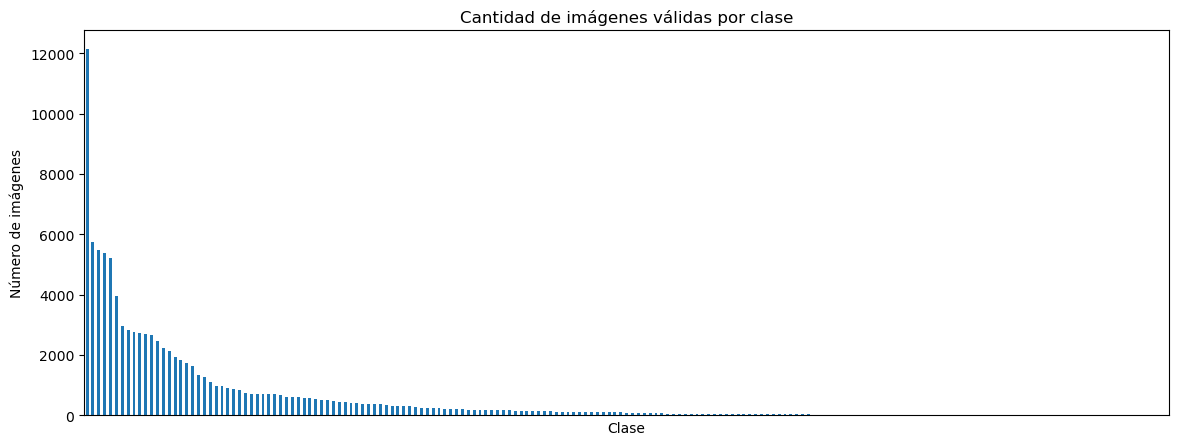

In [6]:
conteo_original = df["clase"].value_counts()

print("Imágenes válidas:", len(df))
print("Clases encontradas:", df["clase"].nunique())
display(conteo_original.describe())

plt.figure(figsize=(14, 5))
conteo_original.sort_values(ascending=False).plot(kind="bar")
plt.title("Cantidad de imágenes válidas por clase")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks([])
plt.show()

In [7]:
clases_validas = conteo_original[
    conteo_original >= CFG.min_imagenes_por_clase
].index

df_limpio = (
    df[df["clase"].isin(clases_validas)]
    .copy()
    .reset_index(drop=True)
)

nombres_clases = sorted(df_limpio["clase"].unique())
clase_a_indice = {nombre: i for i, nombre in enumerate(nombres_clases)}
indice_a_clase = {i: nombre for nombre, i in clase_a_indice.items()}

df_limpio["label"] = df_limpio["clase"].map(clase_a_indice)

print(f"Imágenes después del filtro de clases: {len(df_limpio):,}")
print(f"Número final de clases: {len(nombres_clases)}")

if len(nombres_clases) < 2:
    raise RuntimeError(
        "Quedaron menos de 2 clases. "
        "Reduce min_imagenes_por_clase o revisa la muestra descargada."
    )

Imágenes después del filtro de clases: 99,541
Número final de clases: 138


In [8]:
df_train, df_val = train_test_split(
    df_limpio,
    test_size=CFG.proporcion_validacion,
    random_state=CFG.seed,
    stratify=df_limpio["label"],
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

print(f"Entrenamiento: {len(df_train):,} imágenes")
print(f"Validación   : {len(df_val):,} imágenes")
print(f"Clases train : {df_train['label'].nunique()}")
print(f"Clases val   : {df_val['label'].nunique()}")

Entrenamiento: 79,632 imágenes
Validación   : 19,909 imágenes
Clases train : 138
Clases val   : 138


## 5. Transformaciones y `Dataset`

### Entrenamiento
Se usa *data augmentation* para aumentar la variabilidad:

- recorte aleatorio
- volteo horizontal y vertical
- rotación
- variación moderada de brillo, contraste y saturación

### Validación
No se usa *augmentation*. Solo redimensionado, recorte central y normalización.

La normalización usa las medias y desviaciones estándar habituales de ImageNet.

In [9]:
MEDIA_IMAGENET = [0.485, 0.456, 0.406]
STD_IMAGENET = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.RandomResizedCrop(
        CFG.image_size,
        scale=(0.70, 1.0),
        ratio=(0.85, 1.15),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.20),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.05,
    ),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_IMAGENET, STD_IMAGENET),
])

transform_val = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(CFG.image_size),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_IMAGENET, STD_IMAGENET),
])


class DatasetImagenes(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, indice):
        fila = self.df.iloc[indice]

        with Image.open(fila["ruta"]) as imagen:
            imagen = imagen.convert("RGB")

        if self.transform:
            imagen = self.transform(imagen)

        etiqueta = int(fila["label"])
        return imagen, etiqueta


dataset_train = DatasetImagenes(df_train, transform_train)
dataset_val = DatasetImagenes(df_val, transform_val)

In [10]:
usar_pin_memory = DEVICE.type == "cuda"

loader_train = DataLoader(
    dataset_train,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=usar_pin_memory,
    persistent_workers=False,
)

loader_val = DataLoader(
    dataset_val,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=usar_pin_memory,
    persistent_workers=False,
)

imagenes, etiquetas = next(iter(loader_train))

print("Batch de imágenes:", imagenes.shape)
print("Batch de etiquetas:", etiquetas.shape)

Batch de imágenes: torch.Size([64, 3, 224, 224])
Batch de etiquetas: torch.Size([64])


## 6. Visualización de ejemplos

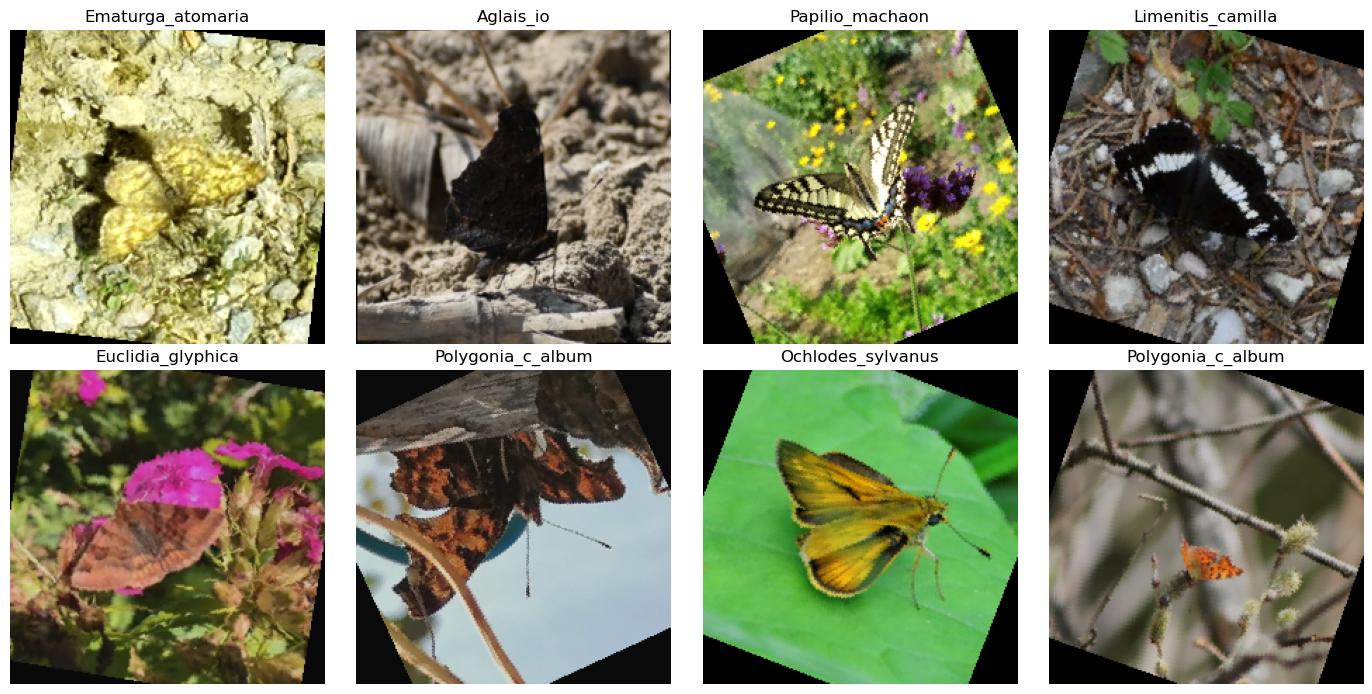

In [11]:
def desnormalizar(tensor: torch.Tensor) -> torch.Tensor:
    media = torch.tensor(MEDIA_IMAGENET).view(3, 1, 1)
    std = torch.tensor(STD_IMAGENET).view(3, 1, 1)
    return (tensor.cpu() * std + media).clamp(0, 1)


imagenes, etiquetas = next(iter(loader_train))

cantidad = min(8, len(imagenes))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(cantidad):
    imagen = desnormalizar(imagenes[i]).permute(1, 2, 0)
    axes[i].imshow(imagen)
    axes[i].set_title(indice_a_clase[int(etiquetas[i])])
    axes[i].axis("off")

for i in range(cantidad, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 7. CNN

La arquitectura usa cuatro bloques convolucionales:

```text
Imagen RGB
   ↓
Conv → BN → ReLU → Conv → BN → ReLU → MaxPool
   ↓
Conv → BN → ReLU → Conv → BN → ReLU → MaxPool
   ↓
Conv → BN → ReLU → Conv → BN → ReLU → MaxPool
   ↓
Conv → BN → ReLU → Conv → BN → ReLU → MaxPool
   ↓
Adaptive Average Pooling
   ↓
Fully Connected → Dropout
   ↓
N clases
```

`AdaptiveAvgPool2d(1)` evita depender de un tamaño espacial fijo antes del clasificador.

In [12]:
class BloqueConvolucional(nn.Module):
    def __init__(self, canales_entrada: int, canales_salida: int, dropout: float = 0.0):
        super().__init__()

        self.bloque = nn.Sequential(
            nn.Conv2d(
                canales_entrada,
                canales_salida,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(canales_salida),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                canales_salida,
                canales_salida,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(canales_salida),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2),

            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
        )

    def forward(self, x):
        return self.bloque(x)


class CNNClasificador(nn.Module):
    def __init__(self, n_clases: int, dropout: float = 0.40):
        super().__init__()

        self.extractor = nn.Sequential(
            BloqueConvolucional(3, 32, dropout=0.05),
            BloqueConvolucional(32, 64, dropout=0.10),
            BloqueConvolucional(64, 128, dropout=0.15),
            BloqueConvolucional(128, 256, dropout=0.20),
        )

        self.pool_global = nn.AdaptiveAvgPool2d(1)

        self.clasificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, n_clases),
        )

    def forward(self, x):
        x = self.extractor(x)
        x = self.pool_global(x)
        x = self.clasificador(x)
        return x


modelo = CNNClasificador(
    n_clases=len(nombres_clases),
    dropout=CFG.dropout,
).to(DEVICE)

modelo

CNNClasificador(
  (extractor): Sequential(
    (0): BloqueConvolucional(
      (bloque): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.05, inplace=False)
      )
    )
    (1): BloqueConvolucional(
      (bloque): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3):

In [13]:
def contar_parametros(modelo: nn.Module) -> int:
    return sum(p.numel() for p in modelo.parameters() if p.requires_grad)


print(f"Parámetros entrenables: {contar_parametros(modelo):,}")

Parámetros entrenables: 1,274,474


## 8. Pesos de clase, Adam y Learning Rate Scheduling

El dataset es desbalanceado, por lo que se calculan pesos de clase usando únicamente
el conjunto de entrenamiento.

Se utiliza:

- `CrossEntropyLoss` con pesos de clase
- *Label smoothing*
- `Adam`
- *Weight decay*
- `ReduceLROnPlateau`

In [14]:
clases_numericas = np.arange(len(nombres_clases))

pesos = compute_class_weight(
    class_weight="balanced",
    classes=clases_numericas,
    y=df_train["label"].to_numpy(),
)

pesos_tensor = torch.tensor(
    pesos,
    dtype=torch.float32,
    device=DEVICE,
)

criterio = nn.CrossEntropyLoss(
    weight=pesos_tensor,
    label_smoothing=CFG.label_smoothing,
)

optimizador = torch.optim.Adam(
    modelo.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

print("LR inicial:", optimizador.param_groups[0]["lr"])

LR inicial: 0.001


## 9. Entrenador

Incluye:

- entrenamiento y validación por época
- mixed precision en CUDA
- gradient clipping
- scheduler
- early stopping
- guardado automático del mejor modelo

In [15]:
class EarlyStopping:
    def __init__(self, paciencia: int = 5, min_delta: float = 0.0):
        self.paciencia = paciencia
        self.min_delta = min_delta
        self.mejor_loss = math.inf
        self.epocas_sin_mejora = 0

    def actualizar(self, val_loss: float) -> bool:
        mejoro = val_loss < (self.mejor_loss - self.min_delta)

        if mejoro:
            self.mejor_loss = val_loss
            self.epocas_sin_mejora = 0
        else:
            self.epocas_sin_mejora += 1

        return self.epocas_sin_mejora >= self.paciencia


class EntrenadorCNN:
    def __init__(
        self,
        modelo,
        criterio,
        optimizador,
        scheduler,
        dispositivo,
        max_norm_gradiente=1.0,
        paciencia_early_stopping=5,
        ruta_checkpoint="mejor_cnn_butterflies.pt",
    ):
        self.modelo = modelo
        self.criterio = criterio
        self.optimizador = optimizador
        self.scheduler = scheduler
        self.dispositivo = dispositivo
        self.max_norm_gradiente = max_norm_gradiente
        self.ruta_checkpoint = ruta_checkpoint

        self.early_stopping = EarlyStopping(
            paciencia=paciencia_early_stopping
        )

        self.usar_amp = dispositivo.type == "cuda"
        self.scaler = torch.amp.GradScaler(
            "cuda",
            enabled=self.usar_amp,
        )

        self.historial = {
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": [],
            "lr": [],
        }

    def _paso_epoca(self, loader, entrenar: bool):
        if entrenar:
            self.modelo.train()
        else:
            self.modelo.eval()

        perdida_total = 0.0
        correctos = 0
        total = 0

        contexto_gradientes = torch.enable_grad() if entrenar else torch.no_grad()

        with contexto_gradientes:
            for imagenes, etiquetas in tqdm(
                loader,
                leave=False,
                desc="Train" if entrenar else "Val",
            ):
                imagenes = imagenes.to(
                    self.dispositivo,
                    non_blocking=self.dispositivo.type == "cuda",
                )
                etiquetas = etiquetas.to(
                    self.dispositivo,
                    non_blocking=self.dispositivo.type == "cuda",
                )

                if entrenar:
                    self.optimizador.zero_grad(set_to_none=True)

                with torch.autocast(
                    device_type=self.dispositivo.type,
                    dtype=torch.float16,
                    enabled=self.usar_amp,
                ):
                    logits = self.modelo(imagenes)
                    loss = self.criterio(logits, etiquetas)

                if entrenar:
                    self.scaler.scale(loss).backward()

                    self.scaler.unscale_(self.optimizador)
                    torch.nn.utils.clip_grad_norm_(
                        self.modelo.parameters(),
                        max_norm=self.max_norm_gradiente,
                    )

                    self.scaler.step(self.optimizador)
                    self.scaler.update()

                batch_size = etiquetas.size(0)
                perdida_total += loss.item() * batch_size

                predicciones = logits.argmax(dim=1)
                correctos += (predicciones == etiquetas).sum().item()
                total += batch_size

        loss_promedio = perdida_total / total
        accuracy = correctos / total

        return loss_promedio, accuracy

    def entrenar(self, loader_train, loader_val, epochs: int):
        for epoca in range(1, epochs + 1):
            train_loss, train_acc = self._paso_epoca(
                loader_train,
                entrenar=True,
            )

            val_loss, val_acc = self._paso_epoca(
                loader_val,
                entrenar=False,
            )

            self.scheduler.step(val_loss)
            lr_actual = self.optimizador.param_groups[0]["lr"]

            self.historial["train_loss"].append(train_loss)
            self.historial["train_acc"].append(train_acc)
            self.historial["val_loss"].append(val_loss)
            self.historial["val_acc"].append(val_acc)
            self.historial["lr"].append(lr_actual)

            mejoro = val_loss <= self.early_stopping.mejor_loss

            if mejoro:
                torch.save(
                    {
                        "model_state_dict": self.modelo.state_dict(),
                        "clase_a_indice": clase_a_indice,
                        "config": vars(CFG),
                        "val_loss": val_loss,
                        "val_acc": val_acc,
                        "epoca": epoca,
                    },
                    self.ruta_checkpoint,
                )

            detener = self.early_stopping.actualizar(val_loss)

            print(
                f"Época {epoca:02d}/{epochs} | "
                f"train_loss={train_loss:.4f} | "
                f"train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f} | "
                f"lr={lr_actual:.2e}"
            )

            if detener:
                print(
                    f"Early stopping: sin mejora durante "
                    f"{self.early_stopping.paciencia} épocas."
                )
                break

        print(f"Mejor checkpoint: {self.ruta_checkpoint}")
        return self.historial

    def cargar_mejor_modelo(self):
        checkpoint = torch.load(
            self.ruta_checkpoint,
            map_location=self.dispositivo,
            weights_only=False,
        )
        self.modelo.load_state_dict(checkpoint["model_state_dict"])
        print(
            f"Modelo restaurado desde época {checkpoint['epoca']} | "
            f"val_loss={checkpoint['val_loss']:.4f} | "
            f"val_acc={checkpoint['val_acc']:.4f}"
        )


entrenador = EntrenadorCNN(
    modelo=modelo,
    criterio=criterio,
    optimizador=optimizador,
    scheduler=scheduler,
    dispositivo=DEVICE,
    max_norm_gradiente=CFG.max_norm_gradiente,
    paciencia_early_stopping=CFG.paciencia_early_stopping,
)

## 10. Entrenamiento

In [17]:
historial = entrenador.entrenar(
    loader_train=loader_train,
    loader_val=loader_val,
    epochs=CFG.epochs,
)

entrenador.cargar_mejor_modelo()

Train:   0%|          | 0/1245 [00:00<?, ?it/s]

Val:   0%|          | 0/312 [00:00<?, ?it/s]

Época 01/30 | train_loss=6.6557 | train_acc=0.0080 | val_loss=6.4654 | val_acc=0.0219 | lr=1.00e-03


Train:   0%|          | 0/1245 [00:00<?, ?it/s]

Val:   0%|          | 0/312 [00:00<?, ?it/s]

Época 02/30 | train_loss=6.5872 | train_acc=0.0096 | val_loss=6.4386 | val_acc=0.0108 | lr=1.00e-03


Train:   0%|          | 0/1245 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 11. Curvas de entrenamiento

In [ ]:
def graficar_historial(historial):
    epocas = range(1, len(historial["train_loss"]) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epocas, historial["train_loss"], label="Train")
    plt.plot(epocas, historial["val_loss"], label="Validación")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title("Loss de entrenamiento y validación")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(epocas, historial["train_acc"], label="Train")
    plt.plot(epocas, historial["val_acc"], label="Validación")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title("Accuracy de entrenamiento y validación")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epocas, historial["lr"])
    plt.xlabel("Época")
    plt.ylabel("Learning rate")
    plt.title("Learning Rate Scheduling")
    plt.yscale("log")
    plt.grid(alpha=0.3)
    plt.show()


graficar_historial(historial)

## 12. Evaluación completa

Las métricas se calculan sobre **validación**.

Para clasificación multiclase:

- **Accuracy**: proporción total de aciertos.
- **Precision / Recall / F1 macro**: cada especie pesa lo mismo.
- **Precision / Recall / F1 weighted**: cada especie pesa según su cantidad de muestras.
- **TP/TN/FP/FN**: se calculan para cada especie como problema *one-vs-rest*.
- **ROC/AUC**: también se calculan *one-vs-rest*.

In [ ]:
class EvaluadorClasificacion:
    def __init__(
        self,
        modelo,
        loader,
        dispositivo,
        nombres_clases,
    ):
        self.modelo = modelo
        self.loader = loader
        self.dispositivo = dispositivo
        self.nombres_clases = nombres_clases
        self.n_clases = len(nombres_clases)

        self.y_true = None
        self.y_pred = None
        self.y_prob = None

    @torch.no_grad()
    def predecir(self):
        self.modelo.eval()

        verdaderas = []
        predichas = []
        probabilidades = []

        for imagenes, etiquetas in tqdm(
            self.loader,
            desc="Evaluando",
        ):
            imagenes = imagenes.to(self.dispositivo)

            logits = self.modelo(imagenes)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            verdaderas.append(etiquetas.numpy())
            predichas.append(preds.cpu().numpy())
            probabilidades.append(probs.cpu().numpy())

        self.y_true = np.concatenate(verdaderas)
        self.y_pred = np.concatenate(predichas)
        self.y_prob = np.concatenate(probabilidades)

        return self.y_true, self.y_pred, self.y_prob

    def metricas_globales(self):
        accuracy = accuracy_score(self.y_true, self.y_pred)

        p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
            self.y_true,
            self.y_pred,
            average="macro",
            zero_division=0,
        )

        p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
            self.y_true,
            self.y_pred,
            average="weighted",
            zero_division=0,
        )

        y_bin = label_binarize(
            self.y_true,
            classes=np.arange(self.n_clases),
        )

        auc_macro = roc_auc_score(
            y_bin,
            self.y_prob,
            average="macro",
            multi_class="ovr",
        )

        auc_weighted = roc_auc_score(
            y_bin,
            self.y_prob,
            average="weighted",
            multi_class="ovr",
        )

        resultados = pd.DataFrame(
            {
                "Métrica": [
                    "Accuracy",
                    "Precision macro",
                    "Recall macro",
                    "F1 macro",
                    "Precision weighted",
                    "Recall weighted",
                    "F1 weighted",
                    "AUC ROC macro (OvR)",
                    "AUC ROC weighted (OvR)",
                ],
                "Valor": [
                    accuracy,
                    p_macro,
                    r_macro,
                    f1_macro,
                    p_weighted,
                    r_weighted,
                    f1_weighted,
                    auc_macro,
                    auc_weighted,
                ],
            }
        )

        return resultados

    def reporte_por_clase(self):
        reporte = classification_report(
            self.y_true,
            self.y_pred,
            labels=np.arange(self.n_clases),
            target_names=self.nombres_clases,
            output_dict=True,
            zero_division=0,
        )

        df_reporte = pd.DataFrame(reporte).T
        return df_reporte

    def tabla_tp_tn_fp_fn(self):
        matrices = multilabel_confusion_matrix(
            self.y_true,
            self.y_pred,
            labels=np.arange(self.n_clases),
        )

        filas = []

        for i, matriz in enumerate(matrices):
            tn, fp, fn, tp = matriz.ravel()

            filas.append(
                {
                    "clase": self.nombres_clases[i],
                    "TP": int(tp),
                    "TN": int(tn),
                    "FP": int(fp),
                    "FN": int(fn),
                }
            )

        return pd.DataFrame(filas)

    def graficar_matriz_confusion(self, normalizada=True):
        normalizar = "true" if normalizada else None

        cm = confusion_matrix(
            self.y_true,
            self.y_pred,
            labels=np.arange(self.n_clases),
            normalize=normalizar,
        )

        plt.figure(figsize=(14, 12))
        plt.imshow(cm, interpolation="nearest", aspect="auto")
        plt.colorbar()

        if self.n_clases <= 30:
            posiciones = np.arange(self.n_clases)
            plt.xticks(
                posiciones,
                self.nombres_clases,
                rotation=90,
                fontsize=7,
            )
            plt.yticks(
                posiciones,
                self.nombres_clases,
                fontsize=7,
            )
        else:
            # Con muchas clases, mostrar todos los nombres hace ilegible la figura.
            plt.xticks([])
            plt.yticks([])

        plt.xlabel("Clase predicha")
        plt.ylabel("Clase real")
        plt.title(
            "Matriz de confusión normalizada"
            if normalizada
            else "Matriz de confusión"
        )
        plt.tight_layout()
        plt.show()

        return cm

    def calcular_roc(self):
        y_bin = label_binarize(
            self.y_true,
            classes=np.arange(self.n_clases),
        )

        fpr = {}
        tpr = {}
        auc_clase = {}

        for i in range(self.n_clases):
            fpr[i], tpr[i], _ = roc_curve(
                y_bin[:, i],
                self.y_prob[:, i],
            )
            auc_clase[i] = auc(fpr[i], tpr[i])

        # Micro-average
        fpr["micro"], tpr["micro"], _ = roc_curve(
            y_bin.ravel(),
            self.y_prob.ravel(),
        )
        auc_micro = auc(fpr["micro"], tpr["micro"])

        # Macro-average
        todos_fpr = np.unique(
            np.concatenate([fpr[i] for i in range(self.n_clases)])
        )

        media_tpr = np.zeros_like(todos_fpr)

        for i in range(self.n_clases):
            media_tpr += np.interp(
                todos_fpr,
                fpr[i],
                tpr[i],
            )

        media_tpr /= self.n_clases

        fpr["macro"] = todos_fpr
        tpr["macro"] = media_tpr
        auc_macro = auc(fpr["macro"], tpr["macro"])

        return fpr, tpr, auc_clase, auc_micro, auc_macro

    def graficar_roc(self, max_clases_individuales=8):
        fpr, tpr, auc_clase, auc_micro, auc_macro = self.calcular_roc()

        plt.figure(figsize=(10, 8))

        plt.plot(
            fpr["micro"],
            tpr["micro"],
            linewidth=3,
            label=f"Micro-average (AUC={auc_micro:.3f})",
        )

        plt.plot(
            fpr["macro"],
            tpr["macro"],
            linewidth=3,
            label=f"Macro-average (AUC={auc_macro:.3f})",
        )

        # Para no saturar la gráfica, se muestran individualmente
        # las clases con más ejemplos en validación.
        conteos_val = np.bincount(
            self.y_true,
            minlength=self.n_clases,
        )
        clases_mas_frecuentes = np.argsort(conteos_val)[::-1][
            :max_clases_individuales
        ]

        for i in clases_mas_frecuentes:
            plt.plot(
                fpr[i],
                tpr[i],
                alpha=0.7,
                label=f"{self.nombres_clases[i]} ({auc_clase[i]:.3f})",
            )

        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Curvas ROC — One-vs-Rest")
        plt.legend(fontsize=8)
        plt.grid(alpha=0.3)
        plt.show()

        df_auc = pd.DataFrame(
            {
                "clase": self.nombres_clases,
                "AUC": [auc_clase[i] for i in range(self.n_clases)],
            }
        ).sort_values("AUC", ascending=False)

        return df_auc


evaluador = EvaluadorClasificacion(
    modelo=modelo,
    loader=loader_val,
    dispositivo=DEVICE,
    nombres_clases=nombres_clases,
)

y_true, y_pred, y_prob = evaluador.predecir()

In [ ]:
metricas = evaluador.metricas_globales()
display(metricas)

In [ ]:
reporte_clases = evaluador.reporte_por_clase()

# Filas correspondientes únicamente a especies.
display(reporte_clases.iloc[:len(nombres_clases)])

In [ ]:
tabla_confusion_binaria = evaluador.tabla_tp_tn_fp_fn()
display(tabla_confusion_binaria)

In [ ]:
matriz_confusion = evaluador.graficar_matriz_confusion(
    normalizada=True
)

In [ ]:
auc_por_clase = evaluador.graficar_roc(
    max_clases_individuales=8
)

display(auc_por_clase)

## 13. Guardar métricas y resultados

In [ ]:
carpeta_resultados = Path("resultados_cnn")
carpeta_resultados.mkdir(exist_ok=True)

metricas.to_csv(
    carpeta_resultados / "metricas_globales.csv",
    index=False,
)

reporte_clases.to_csv(
    carpeta_resultados / "metricas_por_clase.csv",
)

tabla_confusion_binaria.to_csv(
    carpeta_resultados / "tp_tn_fp_fn_por_clase.csv",
    index=False,
)

auc_por_clase.to_csv(
    carpeta_resultados / "auc_por_clase.csv",
    index=False,
)

np.save(
    carpeta_resultados / "matriz_confusion.npy",
    matriz_confusion,
)

with open(
    carpeta_resultados / "clases.json",
    "w",
    encoding="utf-8",
) as archivo:
    json.dump(
        clase_a_indice,
        archivo,
        ensure_ascii=False,
        indent=2,
    )

print("Resultados guardados en:", carpeta_resultados.resolve())

## 14. Predicción de una imagen individual

In [ ]:
def predecir_imagen(
    ruta_imagen: str,
    modelo: nn.Module,
    transform,
    dispositivo,
    indice_a_clase,
    top_k: int = 5,
):
    modelo.eval()

    with Image.open(ruta_imagen) as imagen:
        imagen_rgb = imagen.convert("RGB")

    tensor = transform(imagen_rgb).unsqueeze(0).to(dispositivo)

    with torch.no_grad():
        logits = modelo(tensor)
        probabilidades = torch.softmax(logits, dim=1)[0]

    k = min(top_k, len(indice_a_clase))
    valores, indices = torch.topk(probabilidades, k=k)

    resultados = []

    for prob, indice in zip(valores.cpu(), indices.cpu()):
        resultados.append(
            {
                "clase": indice_a_clase[int(indice)],
                "probabilidad": float(prob),
            }
        )

    plt.figure(figsize=(6, 6))
    plt.imshow(imagen_rgb)
    plt.axis("off")
    plt.title("Imagen a clasificar")
    plt.show()

    return pd.DataFrame(resultados)


# Ejemplo:
# predecir_imagen(
#     "mi_mariposa.jpg",
#     modelo,
#     transform_val,
#     DEVICE,
#     indice_a_clase,
#     top_k=5,
# )

## 15. Recomendaciones para experimentar

Prueba cambios de uno en uno y registra los resultados:

1. Cambiar `batch_size` entre 32, 64 y 128.
2. Probar `learning_rate` entre `1e-4` y `3e-3`.
3. Comparar `Adam` contra `AdamW`.
4. Aumentar o reducir `dropout`.
5. Cambiar el tamaño de entrada de 224 a 256 px.
6. Comparar esta CNN entrenada desde cero con *transfer learning*
   usando ResNet, EfficientNet o ConvNeXt.
7. Aumentar `min_imagenes_por_clase` si las clases minoritarias producen
   métricas demasiado inestables.
8. Si el hardware lo permite, aumentar el límite de imágenes y repetir
   exactamente el mismo protocolo.

Para comparar experimentos correctamente, mantén fija la semilla y la división
train/validation.